In [2]:
import pandas as pd
import numpy as np

In [7]:
import matplotlib.pyplot as plt

In [3]:
expression = pd.read_csv(
    "../data/processed/expression_matrix.csv"
)

metadata = pd.read_csv(
    "../data/processed/sample_metadata_clean.csv"
)

In [4]:
cd4 = metadata[
    (metadata.cell_type=="CD4") &
    (
        metadata.disease.isin(
            [
                "Healthy Control",
                "MS pretreatment"
            ]
        )
    )
]

In [6]:
print(cd4)

     sample geo_accession cell_type          disease   age gender  donorid  \
7    lib229    GSM1479441       CD4  Healthy Control  32.0      F       44   
13   lib235    GSM1479447       CD4  MS pretreatment  52.0      F       31   
54   lib276    GSM1479488       CD4  MS pretreatment  36.0      F       45   
68   lib291    GSM1479502       CD4  Healthy Control  29.0      F       20   
75   lib298    GSM1479509       CD4  Healthy Control  22.0      F       21   
89   lib312    GSM1479523       CD4  Healthy Control  30.0      F       53   
116  lib339    GSM1479550       CD4  MS pretreatment  35.0      F       55   

         race smoker  collection_date  
7    Hispanic     --     June 26 2012  
13      White      Y      May 21 2012  
54      White      N     June 28 2012  
68      White     --  January 25 2012  
75      White     --  February 2 2012  
89      White     --   August 21 2012  
116     White      N   August 23 2012  


In [5]:
samples = cd4["sample"]

expression_cd4 = expression[samples]

(array([3.49544e+05, 5.24000e+02, 1.27000e+02, 5.50000e+01, 2.40000e+01,
        2.20000e+01, 1.40000e+01, 2.00000e+00, 1.00000e+00, 2.00000e+00]),
 array([   0. ,  878.3, 1756.6, 2634.9, 3513.2, 4391.5, 5269.8, 6148.1,
        7026.4, 7904.7, 8783. ]),
 <BarContainer object of 10 artists>)

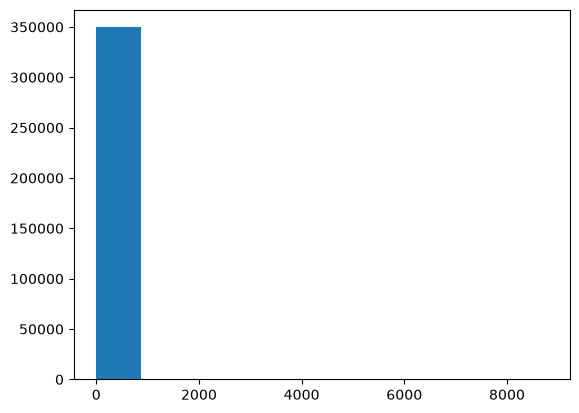

In [8]:
plt.hist(
    expression_cd4.values.flatten()
)

In [9]:
expression_log = np.log2(
    expression_cd4+1
)

In [10]:
mask = (
    expression_cd4>5
).sum(axis=1)>=3

expression_filtered = expression_cd4[mask]

In [11]:
expression_filtered.to_csv(
    "../data/processed/expression_filtered.csv"
)